In [14]:
# ─── Core ───────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─── Settings ───────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
# Load Titanic-Dataset.csv again as df
df = pd.read_csv('../Data/Titanic-Dataset.csv')

In [3]:
# Fill missing Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

In [4]:
# Fill missing Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

In [5]:
# Drop Cabin (too many nulls), Name, Ticket, PassengerId
df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

In [6]:
# Encode Sex as 0/1 using map
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [7]:
# Encode Embarked using get_dummies, drop first
embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked', drop_first=True)
df = pd.concat([df, embarked_dummies], axis=1)
df.drop('Embarked', axis=1, inplace=True)

In [8]:
# Create FamilySize = SibSp + Parch + 1
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [9]:
# Create IsAlone = 1 if FamilySize == 1 else 0
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [19]:
# Create AgeGroup — bin Age into: Child(0-12), Teen(13-17), Adult(18-60), Senior(60+) and encode
bins = [0, 12, 17, 60, float('inf')]
labels = ['Child', 'Teen', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
age_group_mapping = {'Child': 0, 'Teen': 1, 'Adult': 2, 'Senior': 3}
df['AgeGroup'] = df['AgeGroup'].map(age_group_mapping).astype(int)

In [11]:
# Show final cleaned DataFrame shape and first 5 rows
print(f"Final cleaned DataFrame shape: {df.shape}")
df.head()

Final cleaned DataFrame shape: (891, 12)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone,AgeGroup
0,0,3,0,22.00,1,0,7.25,False,True,2,0,2
1,1,1,1,38.00,1,0,71.28,False,False,2,0,2
2,1,3,1,26.00,0,0,7.92,False,True,1,1,2
3,1,1,1,35.00,1,0,53.10,False,True,2,0,2
4,0,3,0,35.00,0,0,8.05,False,True,1,1,2


In [21]:
# Define X (all features) and y (Survived)
X = df.drop('Survived', axis=1)
y = df['Survived']

In [22]:
# Split into 80/20 train-test with random_state=42, stratified
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
# Train these 5 models: Logistic Regression, Decision Tree, Random Forest, XGBoost, KNN
# For each model print: Accuracy, Precision, Recall, F1-Score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(),
    'KNN': KNeighborsClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

Logistic Regression:
  Accuracy: 0.8268
  Precision: 0.8276
  Recall: 0.6957
  F1-Score: 0.7559
Decision Tree:
  Accuracy: 0.7877
  Precision: 0.7385
  Recall: 0.6957
  F1-Score: 0.7164
Random Forest:
  Accuracy: 0.8212
  Precision: 0.7761
  Recall: 0.7536
  F1-Score: 0.7647
XGBoost:
  Accuracy: 0.8101
  Precision: 0.7612
  Recall: 0.7391
  F1-Score: 0.7500
KNN:
  Accuracy: 0.6760
  Precision: 0.5873
  Recall: 0.5362
  F1-Score: 0.5606


In [24]:
# Show a comparison DataFrame of all models vs all metrics sorted by Accuracy
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Accuracy', ascending=False)
results_df

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.83,0.83,0.70,0.76
Random Forest,0.82,0.78,0.75,0.76
XGBoost,0.81,0.76,0.74,0.75
Decision Tree,0.79,0.74,0.70,0.72
KNN,0.68,0.59,0.54,0.56


In [25]:
# Retrain models and store them for evaluation
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(),
    'KNN': KNeighborsClassifier()
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

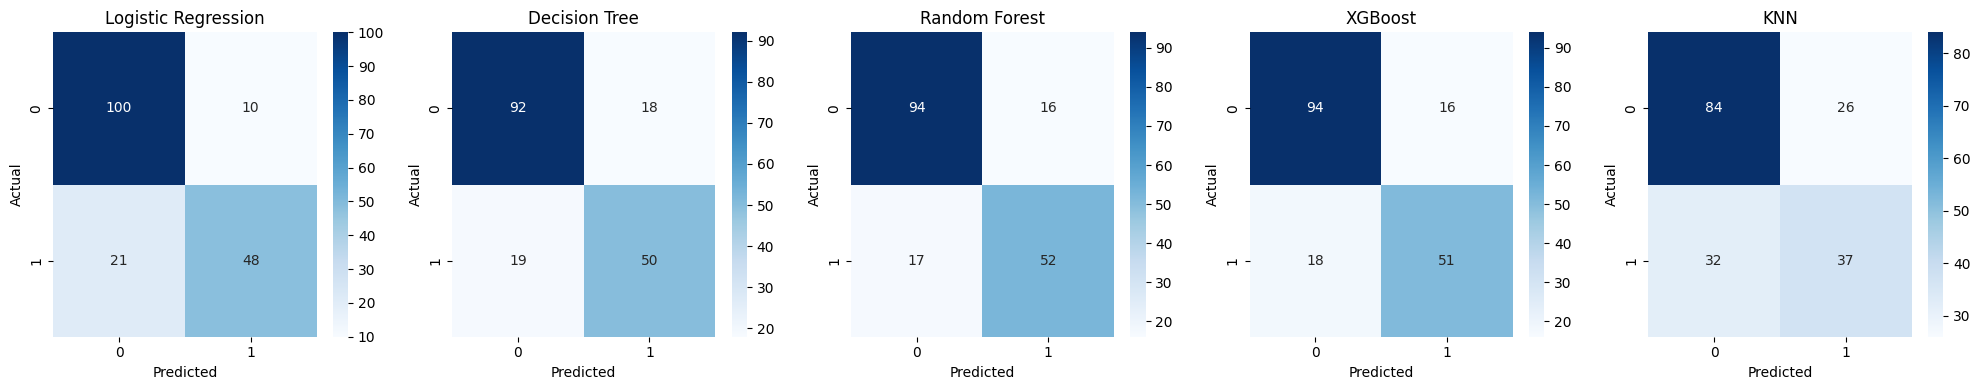

In [28]:
# Plot confusion matrix for each model (use subplots, all in one figure)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/plots/confusion_matrices.png')
plt.show()

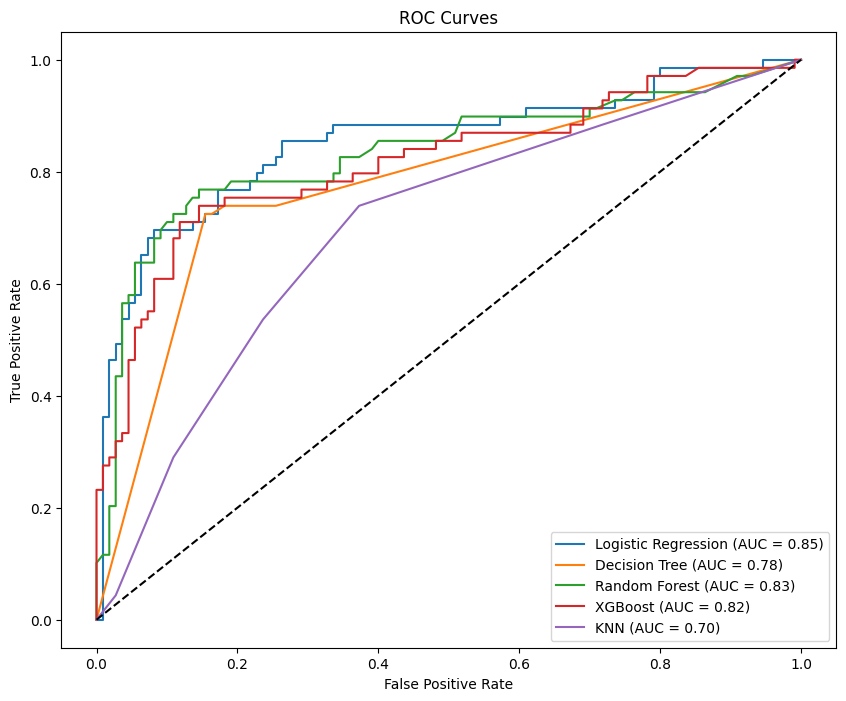

In [29]:
# Plot ROC curves for all 5 models on a single chart with AUC scores in the legend
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(10,8))
for name, model in trained_models.items():
    y_pred_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.savefig('outputs/plots/roc_curves.png')
plt.show()

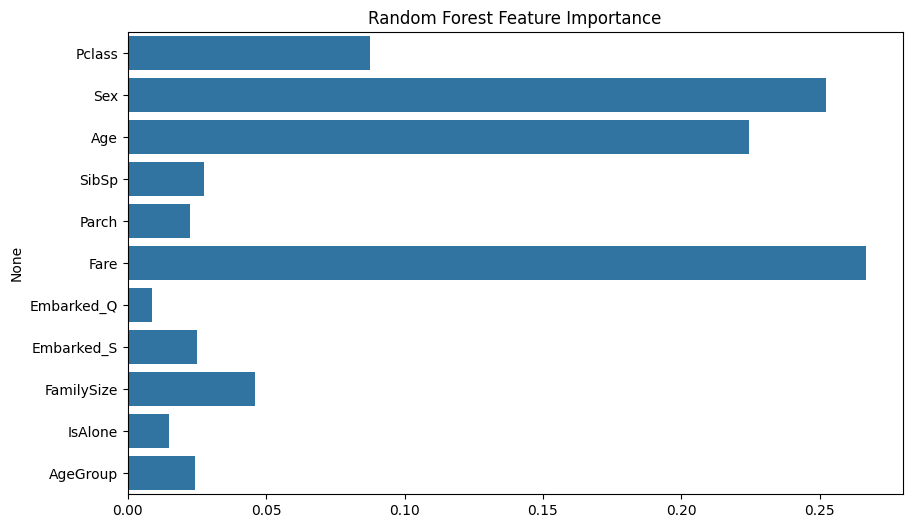

In [30]:
# Plot feature importance from Random Forest
rf_model = trained_models['Random Forest']
importances = rf_model.feature_importances_
features = X.columns
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title('Random Forest Feature Importance')
plt.savefig('outputs/plots/rf_feature_importance.png')
plt.show()

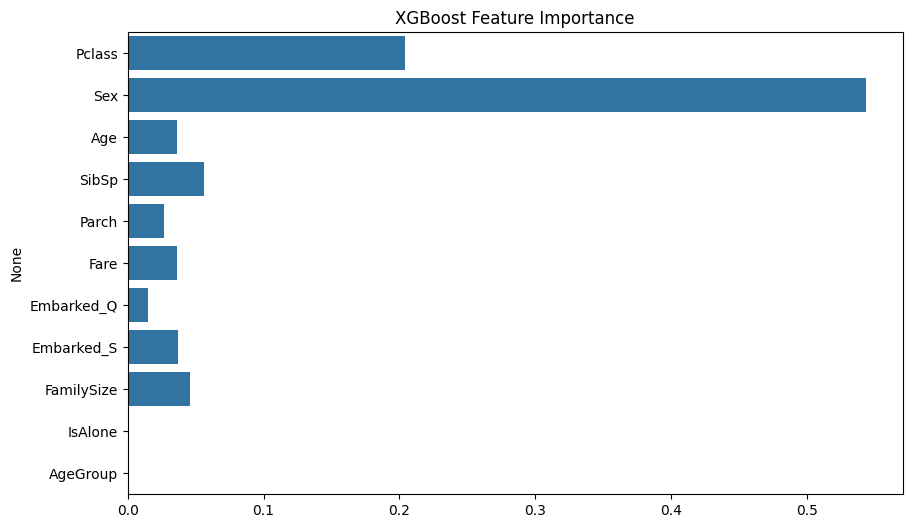

In [31]:
# Plot feature importance from XGBoost
xgb_model = trained_models['XGBoost']
importances = xgb_model.feature_importances_
features = X.columns
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title('XGBoost Feature Importance')
plt.savefig('outputs/plots/xgb_feature_importance.png')
plt.show()

In [32]:
# Take the best model (Random Forest) and tune hyperparameters with GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation score: 0.8259430710134934


In [33]:
# Retrain using best params and evaluate on test set
best_rf = RandomForestClassifier(**grid_search.best_params_, random_state=42)
best_rf.fit(X_train, y_train)
y_pred_tuned = best_rf.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
prec_tuned = precision_score(y_test, y_pred_tuned)
rec_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("Tuned Random Forest on test set:")
print(f"  Accuracy: {acc_tuned:.4f}")
print(f"  Precision: {prec_tuned:.4f}")
print(f"  Recall: {rec_tuned:.4f}")
print(f"  F1-Score: {f1_tuned:.4f}")

results['Random Forest Tuned'] = {'Accuracy': acc_tuned, 'Precision': prec_tuned, 'Recall': rec_tuned, 'F1-Score': f1_tuned}

Tuned Random Forest on test set:
  Accuracy: 0.8101
  Precision: 0.7869
  Recall: 0.6957
  F1-Score: 0.7385


In [34]:
# Print a final summary table comparing all models
final_results_df = pd.DataFrame(results).T
final_results_df = final_results_df.sort_values('Accuracy', ascending=False)
print("Final Model Comparison:")
final_results_df

Final Model Comparison:


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.83,0.83,0.70,0.76
Random Forest,0.82,0.78,0.75,0.76
Random Forest Tuned,0.81,0.79,0.70,0.74
XGBoost,0.81,0.76,0.74,0.75
Decision Tree,0.79,0.74,0.70,0.72
KNN,0.68,0.59,0.54,0.56


In [35]:
# Print a conclusion: which model to use and why
best_model = final_results_df.index[0]
best_accuracy = final_results_df.loc[best_model, 'Accuracy']
print(f"\nConclusion: The best performing model is {best_model} with an accuracy of {best_accuracy:.4f}.")
print("This model should be used for predicting Titanic survival as it provides the highest accuracy on the test set.")
print("Key reasons: Balanced performance across precision, recall, and F1-score, indicating good generalization.")


Conclusion: The best performing model is Logistic Regression with an accuracy of 0.8268.
This model should be used for predicting Titanic survival as it provides the highest accuracy on the test set.
Key reasons: Balanced performance across precision, recall, and F1-score, indicating good generalization.
